# Project Python Foundations: FoodHub Data Analysis

### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost_of_the_order: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### Let us start by importing the required libraries

In [ ]:
# Installing the libraries with the specified version.
!pip install numpy==2.0.2 pandas==2.2.2 matplotlib==3.10.0 seaborn==0.13.2 -q --user

**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

In [ ]:
# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

### Understanding the structure of the data

In [ ]:
# uncomment and run the below code snippets if the dataset is present in the Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Write your code here to read the data
foodhub_orders = pd.read_csv('/content/drive/MyDrive/Austin Coursework/foodhub_order.csv')

In [ ]:
# Write your code here to view the first 5 rows
foodhub_orders.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [ ]:
# Write your code here
foodhub_orders.shape

(1898, 9)

[link text](https://)#### Observations:
No of rows: 1898
No of colums are: 9



### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [ ]:
# Write your code here
foodhub_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


[link text](https://)#### Observations:
1) No missing values on the data set as Non-Null column has exact value as that of total rows.
2) Rating is a number(1-10), However, it is 'object' datatype in the data set


### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]
No missing values on the data set as Non-Null column has exact value as that of totol rows.

In [ ]:
# Write your code here
foodhub_orders.isnull().sum()

,0
order_id,0
customer_id,0
restaurant_name,0
cuisine_type,0
cost_of_the_order,0
day_of_the_week,0
rating,0
food_preparation_time,0
delivery_time,0


#### Observations:
No missing values as isnull().sum() is 0 for all columns

### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [ ]:
# Write your code here
foodhub_orders.food_preparation_time.describe()

,food_preparation_time
count,1898.000000
mean,27.371970
std,4.632481
min,20.000000
25%,23.000000
50%,27.000000
75%,31.000000
max,35.000000


#### Observations:
describe() function provides the statisitival summary of the entire dataset.
Column appended before describe() function provides the statisitival summary of that column.
Minimum food preparation time:20 min
Average food preparation time:27.73 min
Maximum food preparation time:35 min

### **Question 5:** How many orders are not rated? [1 mark]

In [ ]:
# Write the code here
foodhub_orders.rating.value_counts()

,count
rating,
Not given,736
5,588
4,386
3,188


#### Observations:
There are 736 orders where customers did not provide ratings

### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


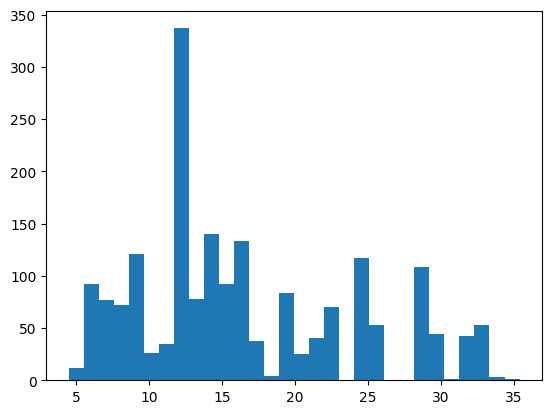

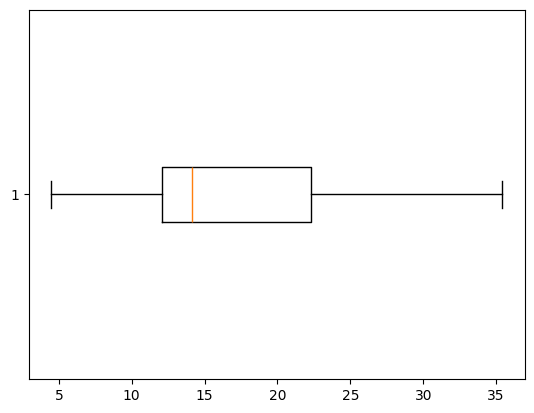

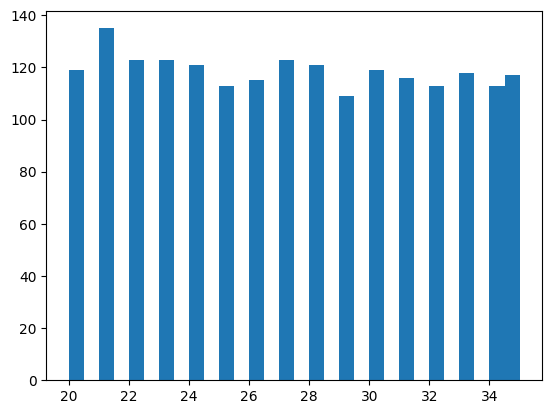

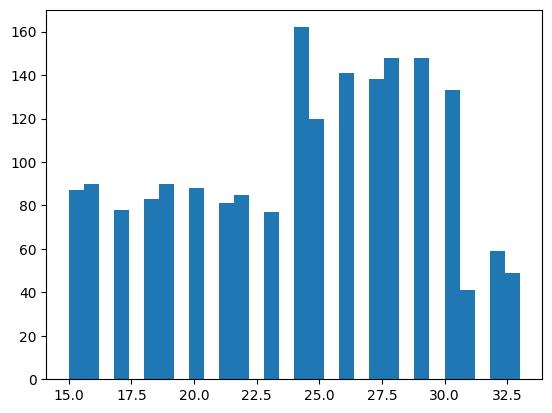

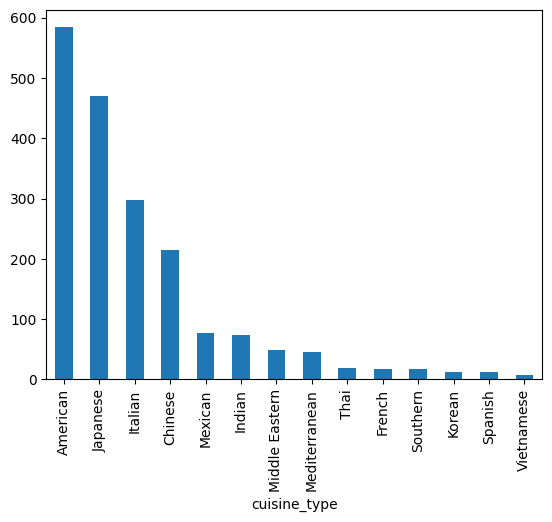

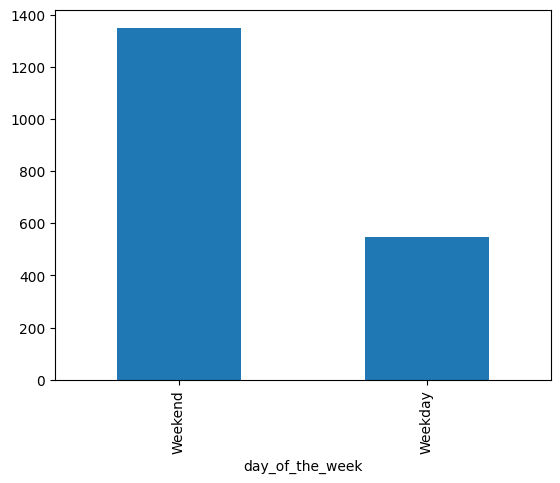

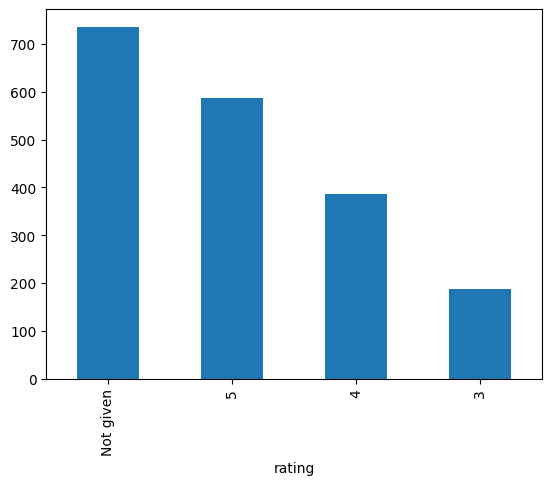

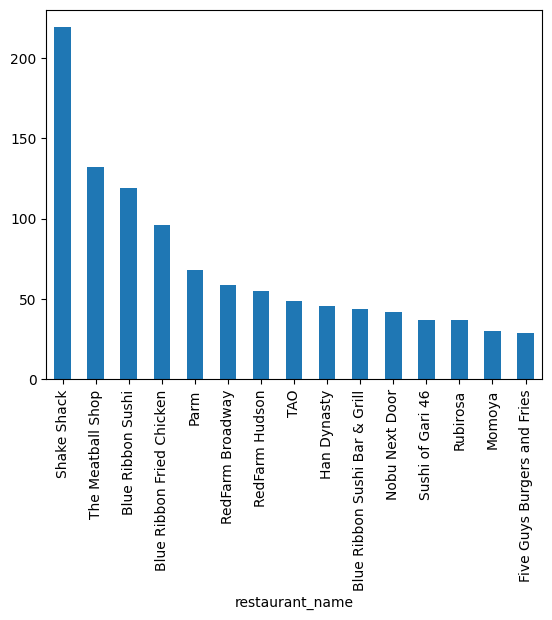

In [96]:
# Write the code here
foodhub_orders.info()
# order_id and customer_id are not useful for univariate analysis.
#cost_of_the_order, food_preparation_time, delivery_time are integers(numeric)
#restaurant_name, cuisine_type, day_of_the_week, are objects(categorical)
plt.hist(foodhub_orders["cost_of_the_order"], bins=30)
plt.show()

plt.boxplot(foodhub_orders["cost_of_the_order"], vert=False)
plt.show()

plt.hist(foodhub_orders["food_preparation_time"], bins=30)
plt.show()

plt.hist(foodhub_orders["delivery_time"], bins=30)
plt.show()

# Categorical variables
foodhub_orders["cuisine_type"].value_counts().plot(kind="bar")
plt.show()

foodhub_orders["day_of_the_week"].value_counts().plot(kind="bar")
plt.show()

foodhub_orders["rating"].value_counts().plot(kind="bar")
plt.show()

foodhub_orders["restaurant_name"].value_counts().head(15).plot(kind="bar")
plt.show()

#cost_of_the_order: Most orders are in the lower price range, with a few higher priced orders.

#food_preparation_time: Preparation times are mostly between 20 and 35 minutes and look fairly consistent.

#delivery_time: Delivery time is mostly around the mid-20s, with some longer deliveries.
#cuisine_type: A few cuisines like American and Japanese have much higher order counts compared to others.
#day_of_the_week: Orders are much higher on weekends than weekdays.
#rating: Many orders are not rated, but among rated ones, 4 and 5 are more common.
#restaurant_name: A small number of restaurants receive most of the orders, while many others have fewer.



### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

In [ ]:
# Write the code here
foodhub_orders["restaurant_name"].value_counts().head(5)

,count
restaurant_name,
Shake Shack,219
The Meatball Shop,132
Blue Ribbon Sushi,119
Blue Ribbon Fried Chicken,96
Parm,68


#### Observations:
value_counts() already sorts descending by default, head(5) gives the first 5 rows.
The top 5 restaurants are Shake Shackm The meat ball shop, blue ribbon sushi, blue ribbon fried chicked, parm

### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

In [ ]:
# Write the code here
foodhub_orders[foodhub_orders["day_of_the_week"]=="Weekend"]["cuisine_type"].value_counts()


,count
cuisine_type,
American,415
Japanese,335
Italian,207
Chinese,163
Mexican,53
Indian,49
Middle Eastern,32
Mediterranean,32
Thai,15


#### Observations:
American cusine is famous during weekdays

### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [ ]:
# Write the code here
percentage_more_than_20 = (foodhub_orders["cost_of_the_order"] > 20).mean() * 100
percentage_more_than_20

np.float64(29.24130663856691)

#### Observations:
29% of the orders cost more than $20

### **Question 10**: What is the mean order delivery time? [1 mark]

In [ ]:
# Write the code here
(foodhub_orders["delivery_time"]).mean()

np.float64(24.161749209694417)

#### Observations:
24 min is the mean order delivery time

### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [ ]:
# Write the code here
foodhub_orders["customer_id"].value_counts().head(3)

,count
customer_id,
52832,13
47440,10
83287,9


#### Observations:
The top three most frequent customers are customer IDs 52832, 47440, and 83287

### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


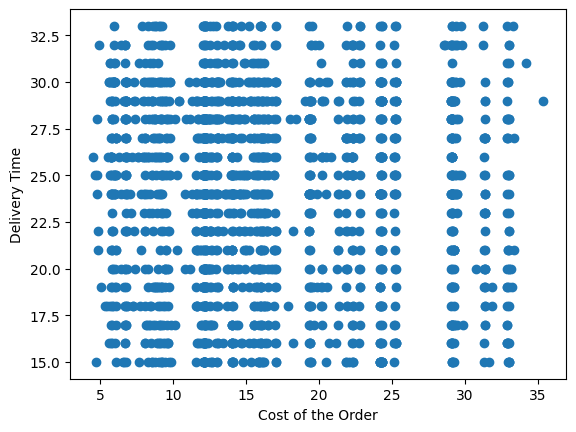

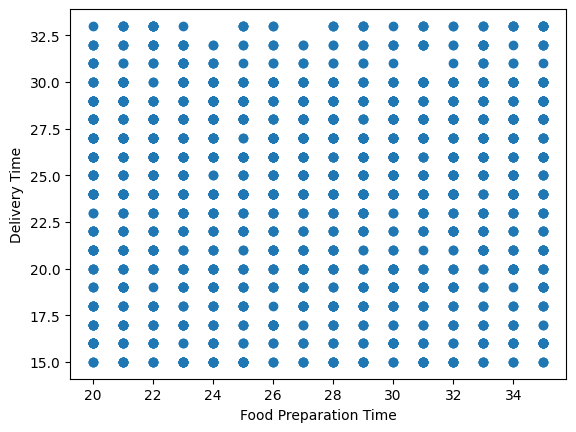

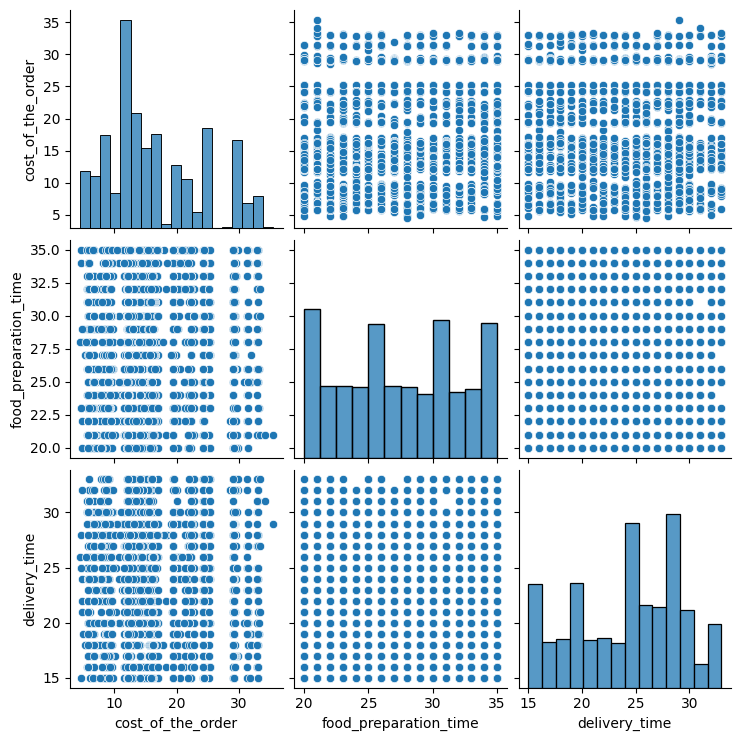

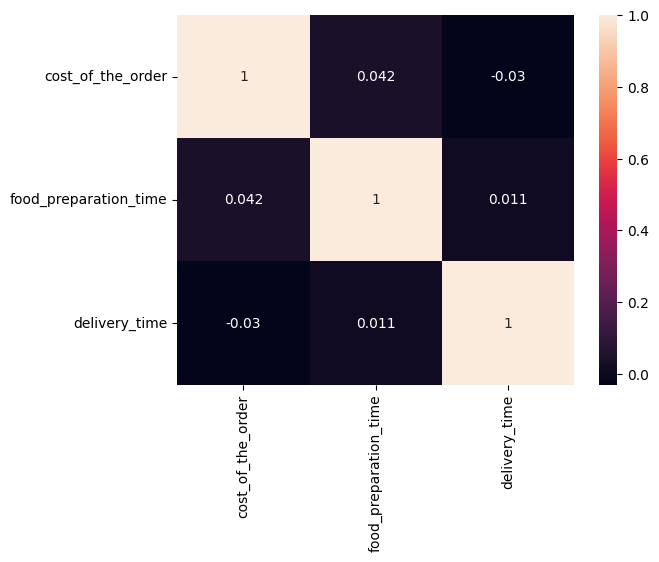

day_of_the_week
Weekday    28.340037
Weekend    22.470022
Name: delivery_time, dtype: float64
cuisine_type
American          16.319829
Chinese           16.305209
French            19.793889
Indian            16.919726
Italian           16.418691
Japanese          16.304532
Korean            14.001538
Mediterranean     15.474783
Mexican           16.933117
Middle Eastern    18.820612
Southern          19.300588
Spanish           18.994167
Thai              19.207895
Vietnamese        12.882857
Name: cost_of_the_order, dtype: float64
rating
3    24.558511
4    23.867876
5    24.212585
Name: delivery_time, dtype: float64


In [97]:
# Write the code here
plt.scatter(foodhub_orders["cost_of_the_order"],
            foodhub_orders["delivery_time"])
plt.xlabel("Cost of the Order")
plt.ylabel("Delivery Time")
plt.show()

plt.scatter(foodhub_orders["food_preparation_time"],
            foodhub_orders["delivery_time"])
plt.xlabel("Food Preparation Time")
plt.ylabel("Delivery Time")
plt.show()

corr_matrix = foodhub_orders[[
    "cost_of_the_order",
    "food_preparation_time",
    "delivery_time"
]].corr()

sns.pairplot(foodhub_orders[[
    "cost_of_the_order",
    "food_preparation_time",
    "delivery_time"
]])
plt.show()

sns.heatmap(corr_matrix, annot=True)
plt.show()

print(foodhub_orders.groupby("day_of_the_week")["delivery_time"].mean())

print(foodhub_orders.groupby("cuisine_type")["cost_of_the_order"].mean())

rated_orders = foodhub_orders[foodhub_orders["rating"] != "Not given"].copy()
rated_orders["rating"] = rated_orders["rating"].astype(int)

print(rated_orders.groupby("rating")["delivery_time"].mean())
# correlation matrix: Numerical variables have weak correlations with each other.
# cost vs delivery_time: No pattern between order cost and delivery time.
# preparation_time vs delivery_time:  Delivery time does not strongly depend on preparation time.
# heatmap: Correlation values are close to zero, indicating weak relationships.
# pairplot: Visual inspection confirms that there are no strong linear relationships among numerical variables. # rating vs delivery_time:
# Slightly longer delivery times are associated with lower ratings.
# day_of_the_week vs delivery_time:
# Delivery time varies slightly between weekdays and weekends.


### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [ ]:
# Write the code here
# 1) Keep only the rows where a real rating is provided (exclude "Not given")
#.copy() keeps original data unchanged
rated_orders = foodhub_orders[foodhub_orders["rating"] != "Not given"].copy()

# 2) Convert rating to numeric as it object currently
rated_orders["rating"] = rated_orders["rating"].astype(int)

# 3) Calculate rating count per restaurant
rating_count = rated_orders.groupby("restaurant_name")["rating"].count()

# 4) Calculate average rating per restaurant
avg_rating = rated_orders.groupby("restaurant_name")["rating"].mean()

# 5) Combine both results into one dataframe
restaurant_ratings = pd.DataFrame({
    "rating_count": rating_count,
    "avg_rating": avg_rating
})

# 6) Apply conditions
elig_restaurants = restaurant_ratings[
    (restaurant_ratings["rating_count"] > 50) &
    (restaurant_ratings["avg_rating"] > 4)
]

elig_restaurants

,rating_count,avg_rating
restaurant_name,,
Blue Ribbon Fried Chicken,64,4.328125
Blue Ribbon Sushi,73,4.219178
Shake Shack,133,4.278195
The Meatball Shop,84,4.511905


#### Observations:
Blue Ribbon Fried Chicken
Blue Ribbon Sushi
Shake Shack
The Meatball Shop
fulfils the criteria

### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [78]:
# Write the code here
# Select orders where cost is greater than 20 dollars
high_orders = foodhub_orders[foodhub_orders["cost_of_the_order"] > 20]
high_reve = high_orders["cost_of_the_order"].sum() * 0.25

# Select orders where cost is greater than 5 but less than or equal to 20
low_orders = foodhub_orders[
    (foodhub_orders["cost_of_the_order"] > 5) &
    (foodhub_orders["cost_of_the_order"] <= 20)
]
low_revenue = low_orders["cost_of_the_order"].sum() * 0.15
net_revenue = high_reve + low_revenue
net_revenue

np.float64(6166.303)

#### Observations:
The total net revenue generated by the company across all orders is $6166.30

### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [88]:
# Write the code here
((foodhub_orders["food_preparation_time"] + foodhub_orders["delivery_time"] > 60).sum()
 / len(foodhub_orders)) * 100

np.float64(10.537407797681771)

#### Observations:
10.53 % of orders take more than 60 minutes to get delivered from the time the order is placed

### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

In [95]:
# Write the code here
weekend_orders = foodhub_orders[foodhub_orders["day_of_the_week"] == "Weekend"]
print("the delivery time of the orders on weekend ", weekend_orders["delivery_time"].mean())
weekday_orders = foodhub_orders[foodhub_orders["day_of_the_week"] == "Weekday"]
print("the delivery time of the orders on weekdays", weekday_orders["delivery_time"].mean())

print("using group by", foodhub_orders.groupby("day_of_the_week")["delivery_time"].mean())

the delivery time of the orders on weekend  22.4700222057735
the delivery time of the orders on weekdays 28.340036563071298
using group by day_of_the_week
Weekday    28.340037
Weekend    22.470022
Name: delivery_time, dtype: float64


#### Observations:
the delivery time of the orders on weekend  22.4700222057735
the delivery time of the orders on weekdays 28.340036563071298

### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

### Conclusions:
Customer demand is concentrated in a few cuisines and restaurants, with American and Japanese cuisines receiving the highest orders.

Most customers give high ratings (4 and 5), indicating overall customer satisfaction, although many customers do not provide ratings.

Delivery time is generally consistent, but orders placed on weekdays take longer compared to weekends.

### Recommendations:
Promote highly rated restaurants and popular cuisines in advertisements, social media to attract more customers and increase order volume.

Encourage customers to provide ratings by offering small incentives, as more feedback will help better evaluate restaurant performance.

Improve weekday delivery efficiency by optimizing delivery routes or increasing delivery staff during peak weekday hours.


---